In [6]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# 1. GEOMETRY UTILS
# ==========================================
def get_high_dim_radius(sigma, dim):
    return sigma * np.sqrt(dim)

def get_random_unit_vector(dim, rng):
    v = rng.randn(dim)
    return v / np.linalg.norm(v)

def get_orthogonal_vector(vec, dim, rng):
    """Generates a random unit vector orthogonal to vec."""
    random_vec = rng.randn(dim)
    vec_unit = vec / np.linalg.norm(vec)
    orth_vec = random_vec - np.dot(random_vec, vec_unit) * vec_unit
    return orth_vec / np.linalg.norm(orth_vec)
    
# ==========================================
# 2. DATA GENERATION
# ==========================================
def generate_prototypes(dim, separation_factor, rng):
    """
    This fixes the locations of the prototypes (mu0, mu1).
    """
    # 1. Calculate Fixed Distance
    # Based on baseline sigma=1.0 logic
    ref_sigma = 1.0
    r_ref = get_high_dim_radius(ref_sigma, dim)
    fixed_distance = separation_factor * (r_ref + r_ref)

    # 2. Define Centroids
    mu0 = np.zeros(dim)
    
    # Random drift direction for Class 1 (Fixed for this experiment run)
    drift_dir = get_random_unit_vector(dim, rng)
    mu1 = mu0 + drift_dir * fixed_distance
    
    return mu0.astype(np.float32), mu1.astype(np.float32)
    
def generate_samples(n_samples, mu0, mu1, sigma_tight, sigma_loose, rng):
    """
    Sample from the defined centroids.
    """
    dim = len(mu0)
    
    # Class 0: Tight
    X0 = rng.randn(n_samples, dim) * sigma_tight + mu0
    
    # Class 1: Loose (The Trap)
    X1 = rng.randn(n_samples, dim) * sigma_loose + mu1
    
    # Concatenate
    X = np.concatenate([X0, X1]).astype(np.float32)
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)]).astype(int)
    
    return X, y

def generate_ood_samples(n_samples, dim, mu0, mu1, distance_scale, rng, sigma=0.001):
    """
    Generate OOD samples equidistant from the fixed prototypes.
    """
    midpoint = (mu0 + mu1) / 2.0
    axis = mu1 - mu0
    orth_dir = get_orthogonal_vector(axis, dim, rng)
    
    dist_between_classes = np.linalg.norm(axis)
    mu_ood = midpoint + orth_dir * (dist_between_classes * distance_scale)
    
    X_ood = rng.randn(n_samples, dim) * sigma + mu_ood
    return X_ood.astype(np.float32)

In [90]:
SCORE_TYPES = ["sim", "ratio", "discount", "inverse_quantile"]
DIM = 10000
SAMPLES_CAL = 500
SAMPLES_TEST = 500
SIGMA_TIGHT = 0.0001
SEPARATION_CONST = 0.0001
OOD_DISTANCE = 500
ALPHA = 0.1

Running t-SNE...


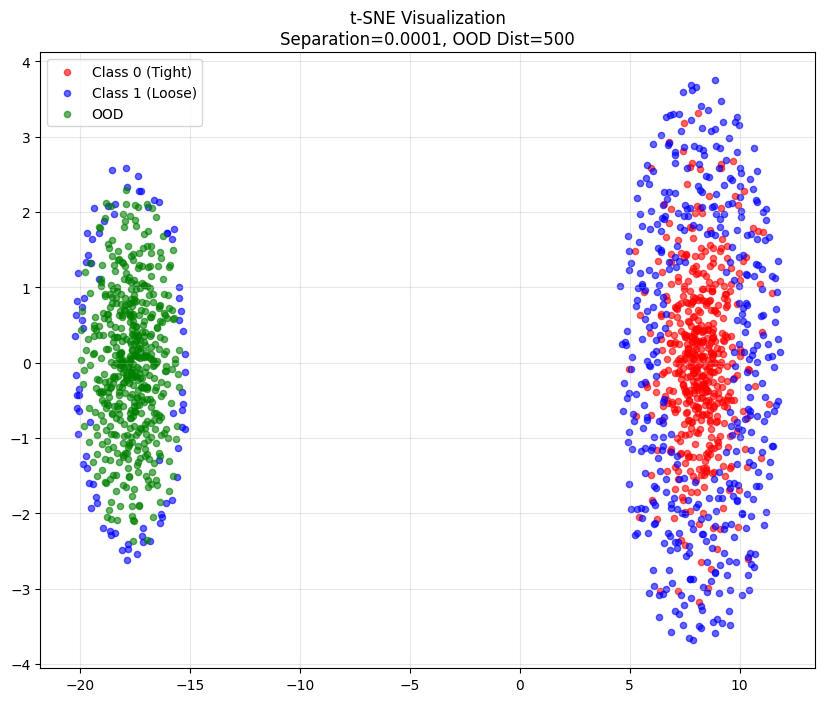

In [93]:
SIGMA_LOOSE = 5
rng = np.random.RandomState(42)

# 1. Generate Prototypes
mu0, mu1 = generate_prototypes(DIM, SEPARATION_CONST, rng)

# 2. Generate In-Distribution Samples
X_in, y_in = generate_samples(SAMPLES_TEST, mu0, mu1, SIGMA_TIGHT, SIGMA_LOOSE, rng)

# 3. Generate OOD Samples
X_ood = generate_ood_samples(SAMPLES_TEST, DIM, mu0, mu1, OOD_DISTANCE, rng)
y_ood = np.full(len(X_ood), 2) # Label 2 for OOD

# 4. Combine for Visualization
X_all = np.concatenate([X_in, X_ood])
y_all = np.concatenate([y_in, y_ood])

# 5. Run t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_embedded = tsne.fit_transform(X_all)

# 6. Plot
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
labels = ['Class 0 (Tight)', 'Class 1 (Loose)', 'OOD']

for i, color, label in zip([0, 1, 2], colors, labels):
    mask = (y_all == i)
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], c=color, label=label, alpha=0.6, s=20)

plt.title(f't-SNE Visualization\nSeparation={SEPARATION_CONST}, OOD Dist={OOD_DISTANCE}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [80]:
def run_single_experiment(seed, sigma_loose):
    # Initialize Random State for this specific run
    # This ensures consistency across the function calls below
    rng = np.random.RandomState(seed)
    
    # -------------------------------------------------
    # 1. SETUP GEOMETRY (The "Distribution")
    # -------------------------------------------------
    # Drift direction is determined HERE and fixed for both Cal and Test
    mu0, mu1 = generate_prototypes(DIM, SEPARATION_CONST, rng)
    
    # -------------------------------------------------
    # 2. SAMPLE DATA (I.I.D Batches)
    # -------------------------------------------------
    # Calibration Batch
    X_cal, y_cal = generate_samples(SAMPLES_CAL, mu0, mu1, SIGMA_TIGHT, sigma_loose, rng)
    
    # Test Batch (New samples, but EXACT same mu0/mu1/sigma)
    X_test, y_test = generate_samples(SAMPLES_TEST, mu0, mu1, SIGMA_TIGHT, sigma_loose, rng)
    
    # OOD Batch
    X_ood = generate_ood_samples(500, DIM, mu0, mu1, OOD_DISTANCE, rng)
    
    # Prototypes (Ground Truth Means)
    prototypes = np.stack([mu0, mu1])
    unique_labels = [0, 1]

    # -------------------------------------------------
    # 3. RUN CONFORMAL HDC
    # -------------------------------------------------
    chdc = ConformalHDC(class_HVs=prototypes, class_labels=unique_labels, 
                        sim_measure="euclidean", random_state=seed)
    
    exp_results = []

    # Loop Score Types
    for stype in SCORE_TYPES:
        chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
        
        # A. Set-Valued Prediction
        for marginal in [True, False]:
            sets = chdc.set_valued_CP(X_test, ALPHA, marginal=marginal)
            sizes = [len(p) for p in sets]
            covered = [1 if y in p else 0 for y, p in zip(y_test, sets)]
            
            # Label conditional coverage
            lc_covs = []
            for lbl in unique_labels:
                lbl_idx = np.where(y_test == lbl)[0]
                if len(lbl_idx) > 0:
                    lc_covs.append(np.mean([covered[i] for i in lbl_idx]))
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "set_valued",
                "marginal": marginal,
                "set_cov": np.mean(covered),
                "set_size": np.mean(sizes),
                "min_class_cov": np.min(lc_covs) if lc_covs else 0.0,
                "point_acc": np.nan, "ood_auroc": np.nan
            })
        
        # B. Point-Valued Prediction
        preds_pt = chdc.point_valued_CP(X_test, 0.05 , allow_empty=False, marginal=False)
        acc_pt = accuracy_score(y_test, np.array(preds_pt).ravel())
        
        exp_results.append({
            "sigma_loose": sigma_loose,
            "score_type": stype,
            "exp": "point_valued",
            "point_acc": acc_pt,
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "min_class_cov": np.nan, "ood_auroc": np.nan
        })
        
        # C. OOD Detection
        for marginal in [True, False]:
            p_vals_id = chdc.get_max_p_value(X_test, marginal=marginal)
            p_vals_ood = chdc.get_max_p_value(X_ood, marginal=marginal)
            
            y_true_roc = np.concatenate([np.ones(len(p_vals_id)), np.zeros(len(p_vals_ood))])
            y_scores_roc = np.concatenate([p_vals_id, p_vals_ood])
            ood_auroc = roc_auc_score(y_true_roc, y_scores_roc)
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "ood",
                "marginal": marginal,
                "ood_auroc": ood_auroc,
                "set_cov": np.nan, "set_size": np.nan, "point_acc": np.nan, 
                "min_class_cov": np.nan
            })

    # 4. Baseline Vanilla HDC
    preds_vanilla = chdc.predict(X_test)
    acc_vanilla = accuracy_score(y_test, preds_vanilla)
    
    exp_results.append({
        "sigma_loose": sigma_loose,
        "score_type": "vanilla",
        "exp": "point_valued",
        "point_acc": acc_vanilla,
        "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
        "min_class_cov": np.nan, "ood_auroc": np.nan
    })
    
    return pd.DataFrame(exp_results)

# ==========================================
# 4. MAIN SWEEP & PLOTTING
# ==========================================

# Sweep Sigma for Class 1 from 1.0 (Equal) to 6.0 (Massive Overlap)
SIGMA_RANGE = np.linspace(1.0, 5, 5)
SEEDS = range(2) 

all_results = []
print(f"Running Gaussian Trap Experiment...")
print(f"Sweeping Sigma Loose: {SIGMA_RANGE}")

for sigma in tqdm(SIGMA_RANGE):
    for seed in SEEDS:
        df = run_single_experiment(seed, sigma)
        all_results.append(df)
final_df = pd.concat(all_results)

Running Gaussian Trap Experiment...
Sweeping Sigma Loose: [1. 2. 3. 4. 5.]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:22<00:00,  4.48s/it]


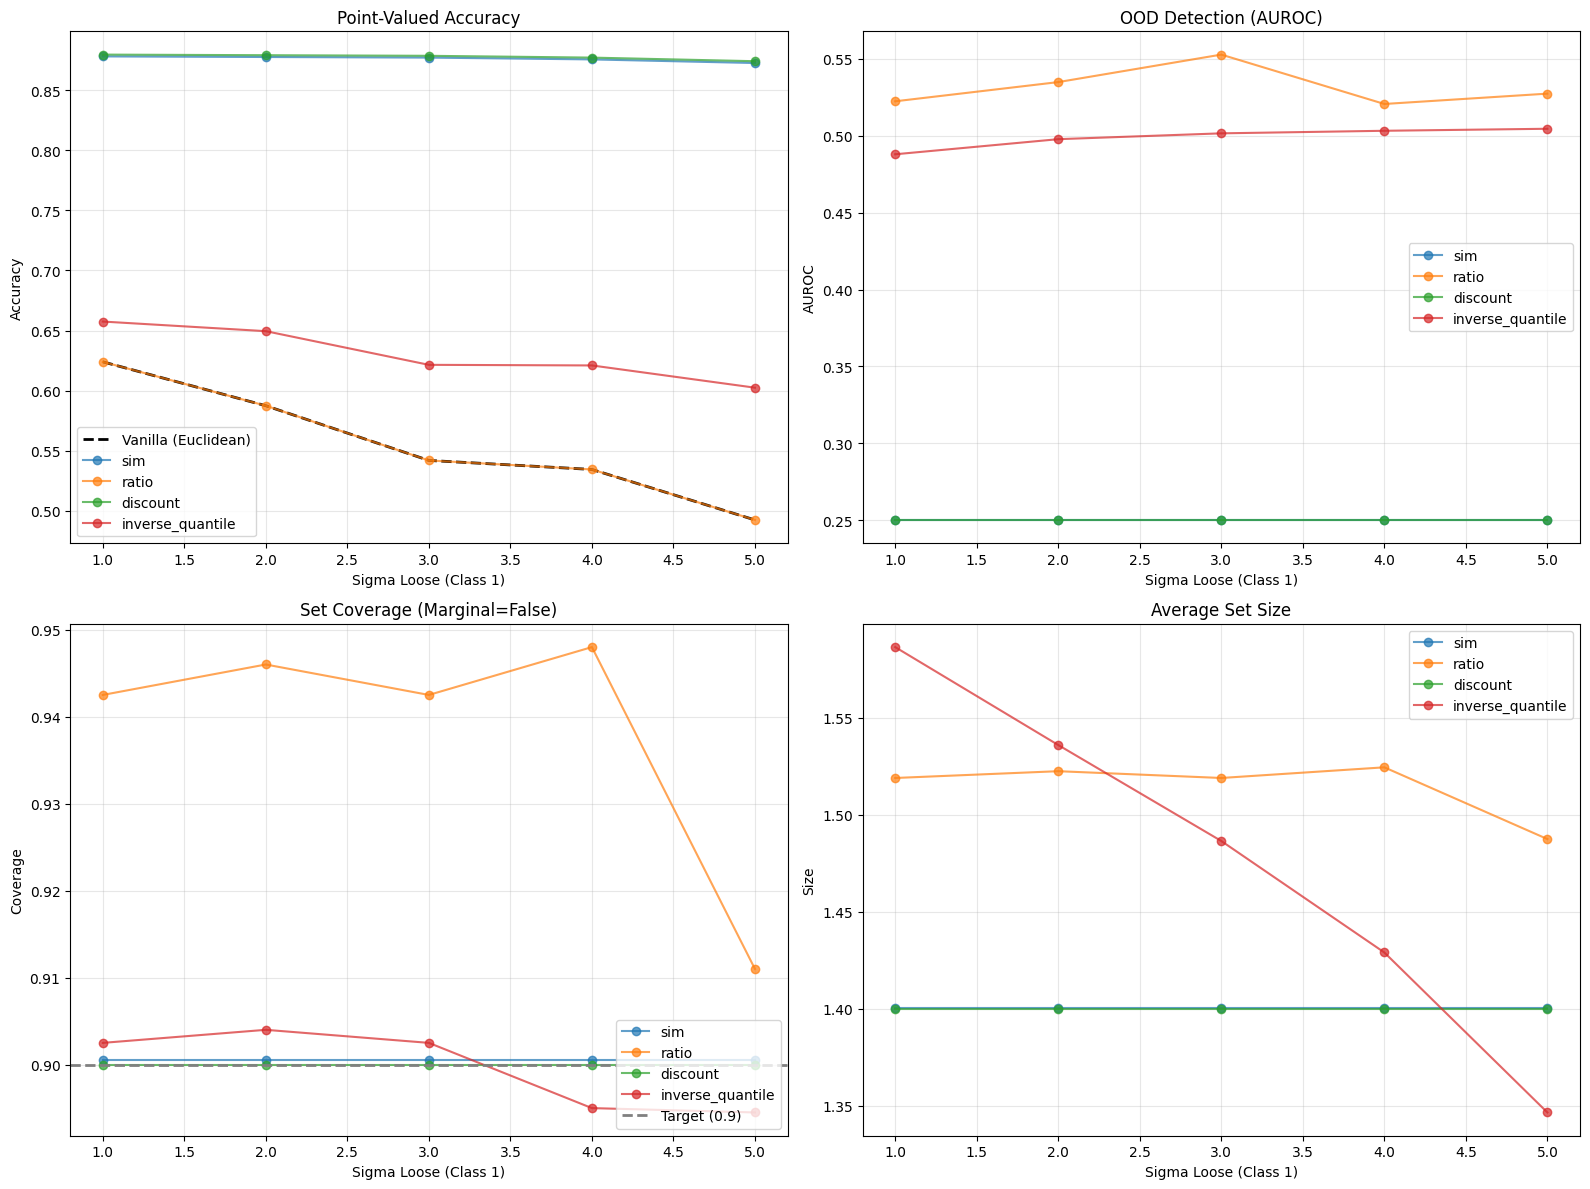

Experiment Complete.


In [81]:
# --- Visualization ---
# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten axes for easier indexing: 
# ax1=Acc, ax2=AUROC, ax3=Cov, ax4=Size
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

# Filter Dataframes
df_pt = final_df[final_df["exp"] == "point_valued"]
df_ood = final_df[(final_df["exp"] == "ood") & (final_df["marginal"] == False)]
df_set = final_df[(final_df["exp"] == "set_valued") & (final_df["marginal"] == False)]

# ----------------------------------------
# Plot 1 (Top-Left): Point-Valued Accuracy
# ----------------------------------------
# Plot Vanilla Baseline
mu_van = df_pt[df_pt["score_type"] == "vanilla"].groupby("sigma_loose")["point_acc"].mean()
ax1.plot(mu_van.index, mu_van.values, 'k--', linewidth=2, label='Vanilla (Euclidean)')

# Plot Conformal Scores
for stype in SCORE_TYPES:
    subset = df_pt[df_pt["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["point_acc"].mean()
        ax1.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax1.set_title("Point-Valued Accuracy")
ax1.set_ylabel("Accuracy")
ax1.set_xlabel("Sigma Loose (Class 1)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ----------------------------------------
# Plot 2 (Top-Right): OOD AUROC
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_ood[df_ood["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["ood_auroc"].mean()
        ax2.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax2.set_title("OOD Detection (AUROC)")
ax2.set_ylabel("AUROC")
ax2.set_xlabel("Sigma Loose (Class 1)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# ----------------------------------------
# Plot 3 (Bottom-Left): Set Coverage
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_set[df_set["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["set_cov"].mean()
        ax3.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)

# Target Line
ax3.axhline(1.0 - ALPHA, color='gray', linestyle='--', linewidth=2, label=f'Target ({1-ALPHA})')

ax3.set_title("Set Coverage (Marginal=False)")
ax3.set_ylabel("Coverage")
ax3.set_xlabel("Sigma Loose (Class 1)")
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right')

# ----------------------------------------
# Plot 4 (Bottom-Right): Set Size
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_set[df_set["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["set_size"].mean()
        ax4.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax4.set_title("Average Set Size")
ax4.set_ylabel("Size")
ax4.set_xlabel("Sigma Loose (Class 1)")
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("Experiment Complete.")